In [1]:
import numpy as np
import matplotlib.pyplot as plt

f0 = 170e3              # Resonant Frequency: 170 kHz
c0 = 343.0              # Speed of sound in air (m/s)
rho0 = 1.204            # Air density (kg/m^3)
wavelength = c0 / f0    # ~2.018 mm
k = 2 * np.pi / wavelength
alpha = 0.4             # Air attenuation (Np/m)

# Transducer parameters
a = 380e-6              # Diaphragm radius: 380 um
xi_0 = 150e-9           # Peak surface displacement: 150 nm
u0 = 2 * np.pi * f0 * xi_0  # Peak surface velocity (~0.16 m/s)
S_m = np.pi * (a ** 2)

# Array geometry (20x20 elements, pitch d = 1.0 mm)
N_side = 20
pitch = 1.0e-3
x_elem = (np.arange(N_side) - (N_side - 1) / 2.0) * pitch
y_elem = (np.arange(N_side) - (N_side - 1) / 2.0) * pitch
X_elem, Y_elem = np.meshgrid(x_elem, y_elem)
r_transducers = np.column_stack((X_elem.ravel(), Y_elem.ravel(), np.zeros(N_side**2)))
num_elements = r_transducers.shape[0]

# Trapped particle properties (Expanded Polystyrene)
R_p = 50e-6             # Particle radius: 50 um
V_p = (4/3) * np.pi * (R_p ** 3)
rho_p = 25.0            # Particle density (kg/m^3)
c_p = 1150.0            # Particle sound speed (m/s)

# Contrast factors
kappa0 = 1.0 / (rho0 * c0**2)
kappa_p = 1.0 / (rho_p * c_p**2)
f1 = 1.0 - (kappa_p / kappa0)
f2 = 2.0 * (rho_p - rho0) / (2.0 * rho_p + rho0)

In [9]:

# Focal Target (Focal trap at z = 30 mm)
r_focus = np.array([0.0, 0.0, 18.0e-3])

# Distance from every transducer to focal point
d_to_focus = np.linalg.norm(r_transducers - r_focus, axis=1)

phi = k * d_to_focus

# Twin-trap split along x-axis (creates the two opposing pressure tweezers)
phi[r_transducers[:, 0] > 0] += np.pi
phi = np.mod(phi, 2 * np.pi)


In [10]:

nx, nz = 161, 161
x_grid = np.linspace(-8e-3, 8e-3, nx)
z_grid = np.linspace(10e-3, 26e-3, nz)
X, Z = np.meshgrid(x_grid, z_grid)
Y = np.zeros_like(X)

P_field = np.zeros_like(X, dtype=complex)

# Directivity calculation helper
def bessel_directivity(ka_sin_theta):
    with np.errstate(divide='ignore', invalid='ignore'):
        val = 2.0 * np.where(ka_sin_theta != 0, 
                             np.vectorize(lambda v: np.i0(v))(ka_sin_theta), 1.0) # placeholder approx or j1
        # Exact J1 directivity:
        from scipy.special import j1
        res = 2.0 * j1(ka_sin_theta) / ka_sin_theta
        res[np.isnan(res)] = 1.0
    return res

from scipy.special import j1

for i in range(num_elements):
    rx = X - r_transducers[i, 0]
    ry = Y - r_transducers[i, 1]
    rz = Z - r_transducers[i, 2]
    d_m = np.sqrt(rx**2 + ry**2 + rz**2)
    
    sin_theta = np.sqrt(rx**2 + ry**2) / d_m
    ka_sin = k * a * sin_theta
    
    D_theta = np.ones_like(ka_sin)
    mask = ka_sin > 1e-6
    D_theta[mask] = 2.0 * j1(ka_sin[mask]) / ka_sin[mask]
    
    # Rayleigh-Sommerfeld integral
    p_elem = (1j * rho0 * c0 * k * S_m / (2 * np.pi)) * (u0 / d_m) * D_theta * np.exp(-(alpha + 1j * k) * d_m + 1j * phi[i])
    P_field += p_elem

abs_p = np.abs(P_field)
dx = x_grid[1] - x_grid[0]
dz = z_grid[1] - z_grid[0]

dp_dx, dp_dz = np.gradient(P_field, dx, dz, axis=(1, 0))
grad_p_sq = np.abs(dp_dx)**2 + np.abs(dp_dz)**2

U = (V_p / 4.0) * ((f1 / (rho0 * c0**2)) * (abs_p**2) - (3.0 * f2 / (2.0 * (2 * np.pi * f0)**2 * rho0)) * grad_p_sq)

dU_dz, dU_dx = np.gradient(U, dz, dx, axis=(0, 1))
Fx = -dU_dx
Fz = -dU_dz


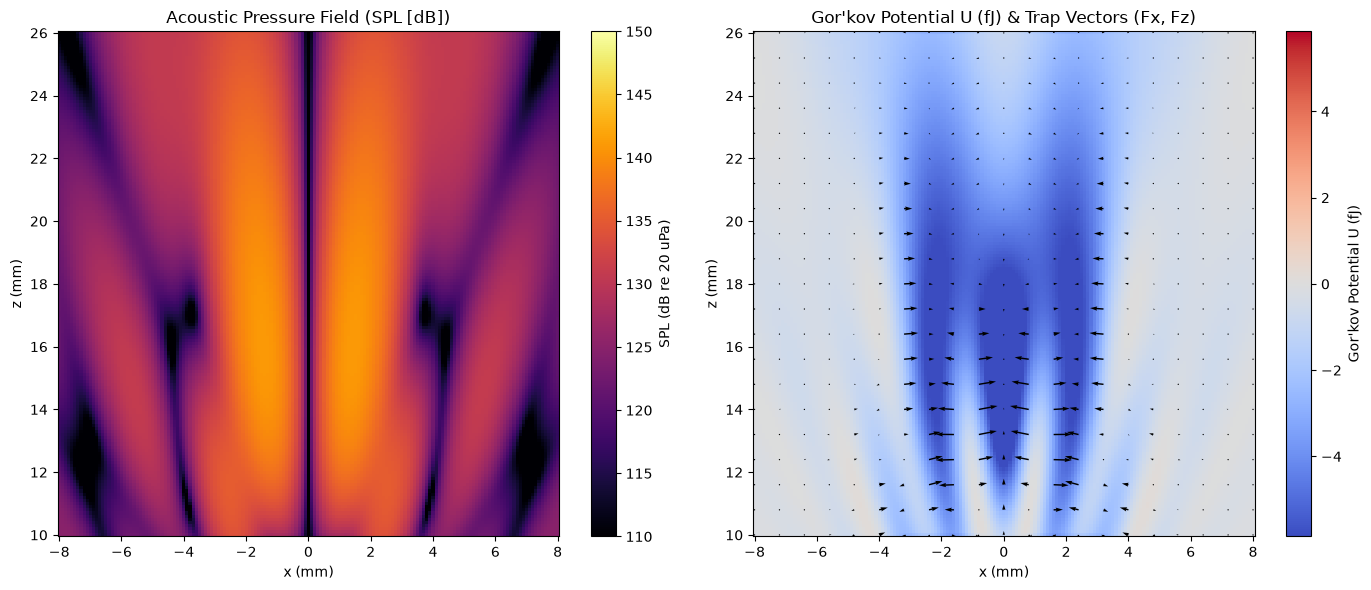

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: Sound Pressure Level with clamped dB scale
spl = 20 * np.log10(np.maximum(abs_p, 1e-9) / 20e-6)
im1 = axes[0].pcolormesh(X * 1e3, Z * 1e3, spl, cmap='inferno', vmin=110, vmax=150, shading='auto')
axes[0].set_title("Acoustic Pressure Field (SPL [dB])")
axes[0].set_xlabel("x (mm)")
axes[0].set_ylabel("z (mm)")
fig.colorbar(im1, ax=axes[0], label="SPL (dB re 20 uPa)")

# Panel 2: Gor'kov Potential with centered colorbar
u_fj = U * 1e15
v_abs = np.percentile(np.abs(u_fj), 95)
im2 = axes[1].pcolormesh(X * 1e3, Z * 1e3, u_fj, cmap='coolwarm', vmin=-v_abs, vmax=v_abs, shading='auto')
axes[1].set_title("Gor'kov Potential U (fJ) & Trap Vectors (Fx, Fz)")
axes[1].set_xlabel("x (mm)")
axes[1].set_ylabel("z (mm)")

skip = 8
axes[1].quiver(X[::skip, ::skip] * 1e3, Z[::skip, ::skip] * 1e3, 
               Fx[::skip, ::skip], Fz[::skip, ::skip], 
               color='black', scale=2e-10)

fig.colorbar(im2, ax=axes[1], label="Gor'kov Potential U (fJ)")
plt.tight_layout()
plt.show()